In [1]:
from functions import *


In [2]:
change_to_parent_dir_once()

base = Path("D:/OneDrive/文档/Synfiles/Project (LTR)/Dataset/almrrc2021/almrrc2021-data-training")

data = load_all_json_dicts(
    base_dir=base,
    output_dir="D:/OneDrive/文档/Synfiles/Project (LTR)/Dataset/almrrc2021/processed_json_pickles",
    rebuild=False
)

Loaded cached: model_apply_inputs__new_package_data, dict len=13
Loaded cached: model_apply_inputs__new_route_data, dict len=13
Loaded cached: model_apply_inputs__new_travel_times, dict len=13
Skipping empty JSON: model_apply_outputs\proposed_sequences.json
Loaded cached: model_build_inputs__actual_sequences, dict len=6112
Loaded cached: model_build_inputs__invalid_sequence_scores, dict len=6112
Loaded cached: model_build_inputs__package_data, dict len=6112
Loaded cached: model_build_inputs__route_data, dict len=6112
Loaded cached: model_build_inputs__travel_times, dict len=6112
Loaded cached: model_score_inputs__new_actual_sequences, dict len=13
Loaded cached: model_score_inputs__new_invalid_sequence_scores, dict len=13
Skipping empty JSON: model_score_outputs\scores.json
Skipping empty JSON: model_score_timings\model_apply_time.json
Skipping empty JSON: model_score_timings\model_build_time.json

Finished. Loaded 10 non-empty JSON dictionaries.


In [ ]:
for name, obj in data.items():
    print(name, type(obj).__name__, len(obj))

In [3]:
package_data = data["model_build_inputs__package_data"]
route_data = data["model_build_inputs__route_data"]
travel_times = data["model_build_inputs__travel_times"]
actual_sequences = data["model_build_inputs__actual_sequences"]

In [ ]:
package_data['RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77'].keys()

In [ ]:
route_data['RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77']['stops']

In [6]:

route_id = "RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77"

# Get stops
stops = route_data[route_id]["stops"]

route_df = (
    pd.DataFrame.from_dict(stops, orient="index")
    .reset_index()
    .rename(columns={"index": "stop_id"})
)

# Get actual visiting sequence
seq_obj = actual_sequences[route_id]

# Handle common ALMRRC format
if isinstance(seq_obj, dict) and "actual" in seq_obj:
    sequence_map = seq_obj["actual"]
else:
    sequence_map = seq_obj

route_df["sequence"] = route_df["stop_id"].map(sequence_map)

# Sort by actual route order
route_ordered = (
    route_df
    .dropna(subset=["sequence"])
    .sort_values("sequence")
    .copy()
)

route_ordered["sequence"] = route_ordered["sequence"].astype(int)

# Remove start station/depot
# Usually station has type == "Station"; also remove sequence == 0 as backup
route_partial = route_ordered[
    (route_ordered["type"].str.lower() != "station") &
    (route_ordered["sequence"] != 0)
].copy()

route_partial.head()

,stop_id,lat,lng,type,zone_id,sequence
89,TG,34.088467,-118.284521,Dropoff,A-2.2A,1
31,GP,34.088709,-118.284839,Dropoff,A-2.2A,2
40,HT,34.088717,-118.286484,Dropoff,A-2.2A,3
2,AG,34.089727,-118.285530,Dropoff,A-2.1A,4
77,QM,34.090901,-118.284257,Dropoff,A-2.1A,5


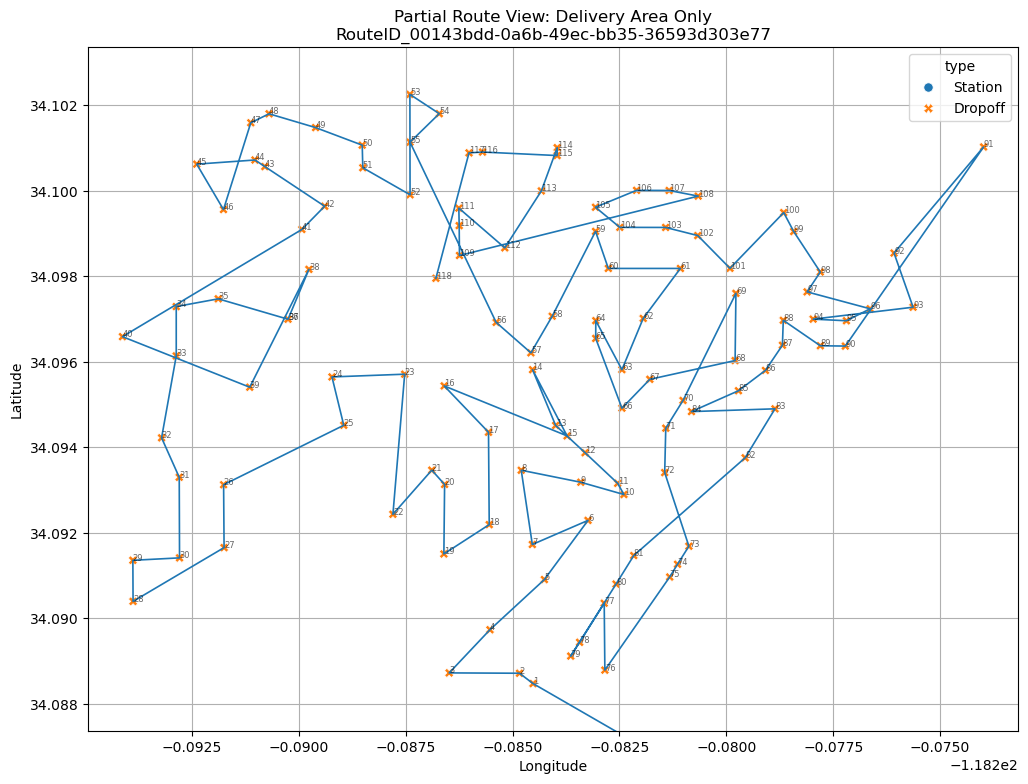

In [5]:

route_id = "RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77"

# Build stop table
stops = route_data[route_id]["stops"]

route_df = (
    pd.DataFrame.from_dict(stops, orient="index")
    .reset_index()
    .rename(columns={"index": "stop_id"})
)

# Add sequence
seq_obj = actual_sequences[route_id]

if isinstance(seq_obj, dict) and "actual" in seq_obj:
    sequence_map = seq_obj["actual"]
else:
    sequence_map = seq_obj

route_df["sequence"] = route_df["stop_id"].map(sequence_map)

route_ordered = (
    route_df
    .dropna(subset=["sequence"])
    .sort_values("sequence")
    .copy()
)

route_ordered["sequence"] = route_ordered["sequence"].astype(int)

# Full route line includes depot
route_line = route_ordered.copy()

# Use only dropoff points to define left-top zoom window
dropoffs = route_ordered[
    route_ordered["type"].str.lower() != "station"
].copy()

# Zoom window from dropoff cluster only
lng_min, lng_max = dropoffs["lng"].min(), dropoffs["lng"].max()
lat_min, lat_max = dropoffs["lat"].min(), dropoffs["lat"].max()

lng_pad = (lng_max - lng_min) * 0.04
lat_pad = (lat_max - lat_min) * 0.08

fig, ax = plt.subplots(figsize=(12, 12))

# Full route line, including depot.
# The part outside the window will be clipped.
sns.lineplot(
    data=route_line,
    x="lng",
    y="lat",
    sort=False,
    estimator=None,
    linewidth=1.2,
    ax=ax
)

# Plot all points.
# Depot exists in data but will be outside the visible window.
sns.scatterplot(
    data=route_line,
    x="lng",
    y="lat",
    hue="type",
    style="type",
    s=45,
    ax=ax
)

# Label only dropoff stops
for _, row in dropoffs.iterrows():
    ax.text(
        row["lng"],
        row["lat"],
        str(row["sequence"]),
        fontsize=6,
        alpha=0.6
    )

# IMPORTANT: set limits after plotting
ax.set_xlim(lng_min - lng_pad, lng_max + lng_pad)
ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)

ax.set_title(f"Partial Route View: Delivery Area Only\n{route_id}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

# Do not use plt.axis("equal") here.
# It can expand the plot back to include the depot.
ax.set_aspect("equal", adjustable="box")

plt.show()

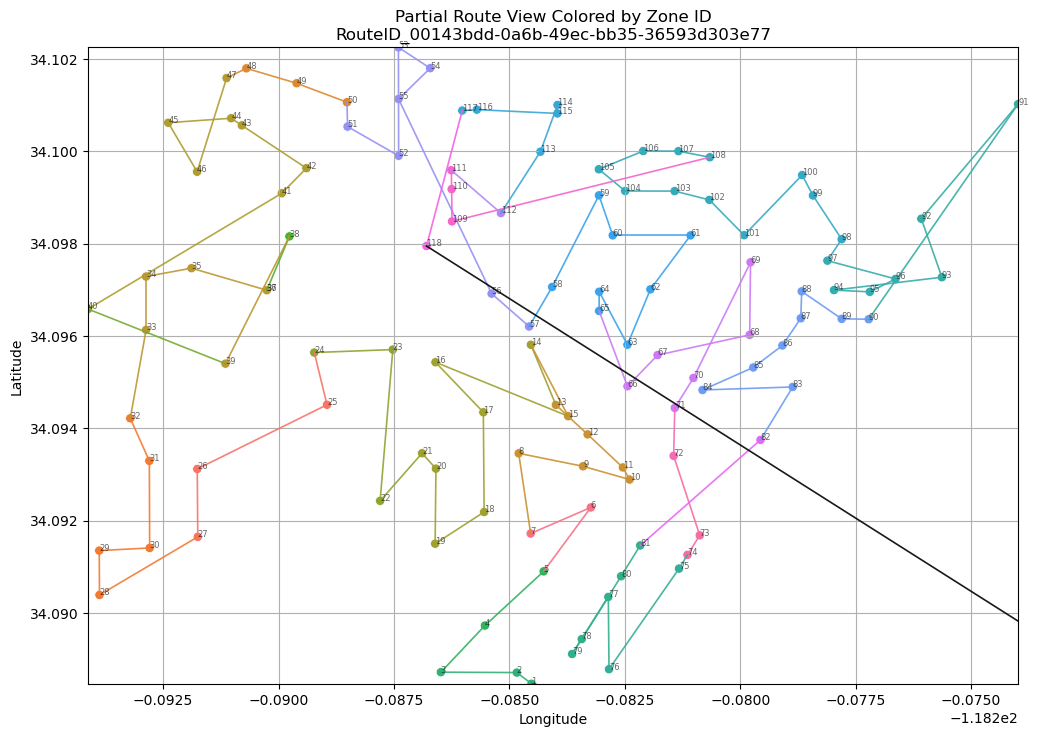

In [ ]:

route_id = "RouteID_00143bdd-0a6b-49ec-bb35-36593d303e77"

# -----------------------------
# 1. Build stop table
# -----------------------------
stops = route_data[route_id]["stops"]

route_df = (
    pd.DataFrame.from_dict(stops, orient="index")
    .reset_index()
    .rename(columns={"index": "stop_id"})
)

# -----------------------------
# 2. Add actual sequence
# -----------------------------
seq_obj = actual_sequences[route_id]

if isinstance(seq_obj, dict) and "actual" in seq_obj:
    sequence_map = seq_obj["actual"]
else:
    sequence_map = seq_obj

route_df["sequence"] = route_df["stop_id"].map(sequence_map)

route_ordered = (
    route_df
    .dropna(subset=["sequence"])
    .sort_values("sequence")
    .copy()
)

route_ordered["sequence"] = route_ordered["sequence"].astype(int)

# -----------------------------
# 3. Full route line includes depot
# -----------------------------
route_line = route_ordered.copy()

# Use only non-station stops to define the visible top-left window
dropoffs = route_ordered[
    route_ordered["type"].str.lower() != "station"
].copy()

# -----------------------------
# 4. Create zone_id -> color map
# -----------------------------
zone_ids = sorted(route_line["zone_id"].dropna().unique())
palette = sns.color_palette("husl", n_colors=len(zone_ids))
zone_color_map = dict(zip(zone_ids, palette))

# Optional: color for depot if zone_id missing
default_color = "black"

# -----------------------------
# 5. Zoom limits from dropoff cluster
# -----------------------------
lng_min, lng_max = dropoffs["lng"].min(), dropoffs["lng"].max()
lat_min, lat_max = dropoffs["lat"].min(), dropoffs["lat"].max()

lng_pad = (lng_max - lng_min) * 0.08
lat_pad = (lat_max - lat_min) * 0.08

fig, ax = plt.subplots(figsize=(12, 12))

# -----------------------------
# 6. Draw line segments
# Each segment color = destination stop's zone_id
# -----------------------------
n = len(route_line)

for i in range(n):
    start = route_line.iloc[i]
    end = route_line.iloc[(i + 1) % n]   # wraps last point back to first point

    # first segment and return segment use the same color
    if i == 0 or i == n - 1:
        seg_zone = route_line.iloc[0]["zone_id"]
    else:
        seg_zone = end["zone_id"]

    seg_color = zone_color_map.get(seg_zone, default_color)

    ax.plot(
        [start["lng"], end["lng"]],
        [start["lat"], end["lat"]],
        color=seg_color,
        linewidth=1.2,
        alpha=0.9
    )

# -----------------------------
# 7. Draw points using same zone colors
# -----------------------------
sns.scatterplot(
    data=route_line,
    x="lng",
    y="lat",
    hue="zone_id",
    palette=zone_color_map,
    s=45,
    ax=ax,
    legend=False
)

# Highlight depot separately if you want
depot = route_line[route_line["type"].str.lower() == "station"]
if not depot.empty:
    ax.scatter(
        depot["lng"],
        depot["lat"],
        s=90,
        marker="s",
        color="black",
        label="Depot",
        zorder=5
    )

# Label only dropoff sequence numbers
for _, row in dropoffs.iterrows():
    ax.text(
        row["lng"],
        row["lat"],
        str(row["sequence"]),
        fontsize=6,
        alpha=0.6
    )

# -----------------------------
# 8. Show only the left-top delivery cluster
# -----------------------------
ax.set_xlim(lng_min - lng_pad, lng_max + lng_pad)
ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)

ax.set_title(f"Partial Route View Colored by Zone ID\n{route_id}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.set_aspect("equal", adjustable="box")

plt.show()

In [8]:
route_line

,stop_id,lat,lng,type,zone_id,sequence
103,VE,34.007369,-118.143927,Station,NaN,0
89,TG,34.088467,-118.284521,Dropoff,A-2.2A,1
31,GP,34.088709,-118.284839,Dropoff,A-2.2A,2
40,HT,34.088717,-118.286484,Dropoff,A-2.2A,3
2,AG,34.089727,-118.285530,Dropoff,A-2.1A,4
...,...,...,...,...,...,...
99,UU,34.101004,-118.283957,Dropoff,P-13.1B,114
84,SD,34.100820,-118.283959,Dropoff,P-13.1B,115
114,YY,34.100902,-118.285704,Dropoff,P-13.1B,116
75,PX,34.100883,-118.286020,Dropoff,P-13.1B,117
